In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [5]:
import pandas as pd

# 100% Working URL
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df  = pd.read_csv(url)

print("=" * 45)
print("✅ Dataset loaded successfully!")
print("=" * 45)
print(f"\n📌 Shape      : {df.shape}")
print(f"📌 Columns    : {df.columns.tolist()}")
print(f"📌 Missing    : {df.isnull().sum().sum()} values")
print("\n📌 Target Distribution:")
print(df["target"].value_counts())
print("\n📌 First 5 Rows:")
display(df.head())

✅ Dataset loaded successfully!

📌 Shape      : (303, 14)
📌 Columns    : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
📌 Missing    : 0 values

📌 Target Distribution:
target
1    165
0    138
Name: count, dtype: int64

📌 First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
print("📌 Data Types & Info:")
display(df.info())

print("\n📌 Descriptive Statistics:")
display(df.describe().round(2))

print("\n📌 Missing Values Per Column:")
print(df.isnull().sum())

print("\n📌 Target Distribution:")
print(df["target"].value_counts())
print("\n  0 = No Heart Disease")
print("  1 = Heart Disease Present")

# Drop duplicates if any
before = len(df)
df = df.drop_duplicates()
after  = len(df)
print(f"\n📌 Duplicates removed: {before - after}")
print(f"📌 Final shape: {df.shape}")

📌 Data Types & Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None


📌 Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00



📌 Missing Values Per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

📌 Target Distribution:
target
1    165
0    138
Name: count, dtype: int64

  0 = No Heart Disease
  1 = Heart Disease Present

📌 Duplicates removed: 1
📌 Final shape: (302, 14)


## 📋 Dataset Column Reference

| Column | Description |
|--------|-------------|
| age | Age of patient |
| sex | Sex (1=male, 0=female) |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120mg (1=true) |
| restecg | Resting ECG results (0-2) |
| thalach | Max heart rate achieved |
| exang | Exercise induced angina (1=yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels (0-3) |
| thal | Thalassemia type |
| target | 1=Heart Disease, 0=No Heart Disease |

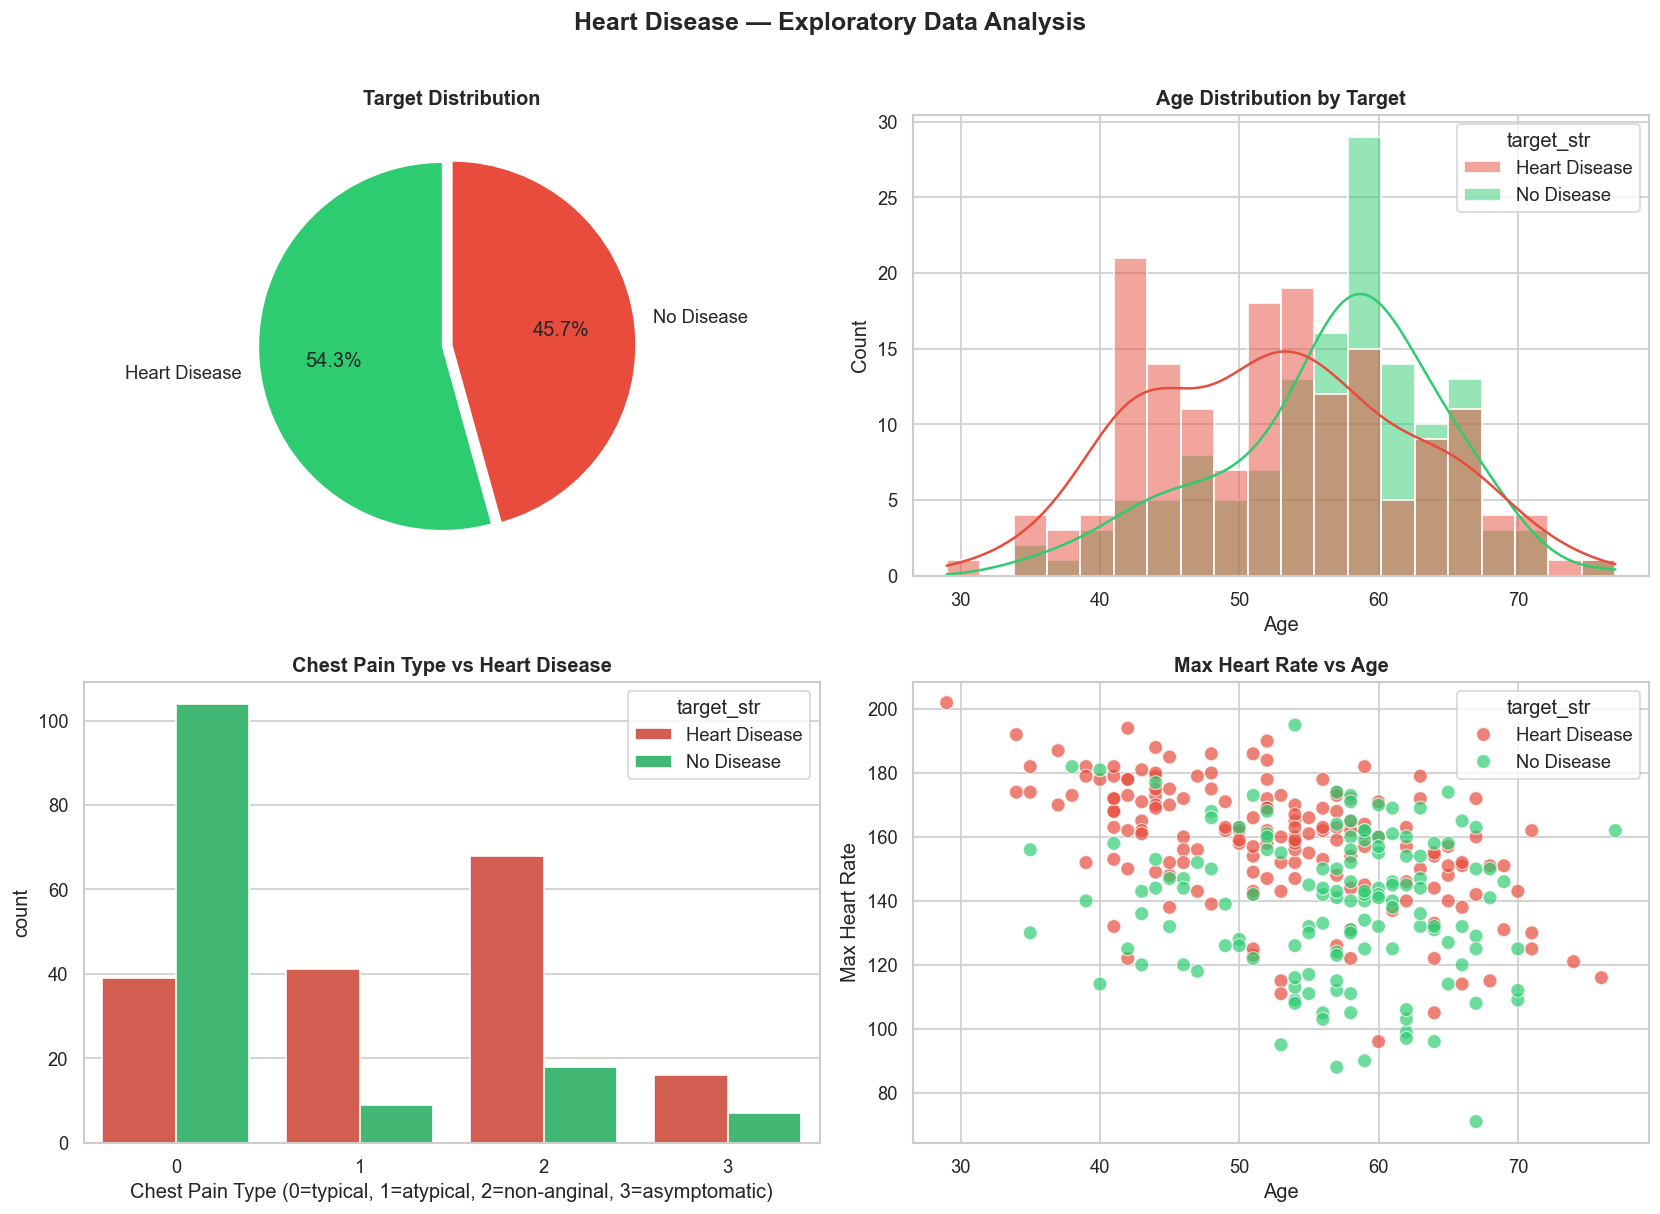

✅ EDA plots done!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Create a clean copy with string target
df_plot = df.copy()
df_plot["target_str"] = df_plot["target"].map({0:"No Disease", 1:"Heart Disease"})

# 1. Target distribution pie chart
target_counts = df_plot["target_str"].value_counts()
axes[0,0].pie(target_counts,
              labels=target_counts.index,
              autopct="%1.1f%%",
              colors=["#2ECC71", "#E74C3C"],
              startangle=90,
              explode=(0.05, 0))
axes[0,0].set_title("Target Distribution", fontweight="bold")

# 2. Age distribution by target
sns.histplot(data=df_plot, x="age",
             hue="target_str",
             bins=20,
             palette={"No Disease":"#2ECC71",
                      "Heart Disease":"#E74C3C"},
             kde=True, ax=axes[0,1])
axes[0,1].set_title("Age Distribution by Target", fontweight="bold")
axes[0,1].set_xlabel("Age")

# 3. Chest pain type vs target
sns.countplot(data=df_plot, x="cp",
              hue="target_str",
              palette={"No Disease":"#2ECC71",
                       "Heart Disease":"#E74C3C"},
              ax=axes[1,0])
axes[1,0].set_title("Chest Pain Type vs Heart Disease", fontweight="bold")
axes[1,0].set_xlabel("Chest Pain Type (0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic)")

# 4. Max heart rate vs age
sns.scatterplot(data=df_plot, x="age", y="thalach",
                hue="target_str",
                palette={"No Disease":"#2ECC71",
                         "Heart Disease":"#E74C3C"},
                alpha=0.7, s=70, ax=axes[1,1])
axes[1,1].set_title("Max Heart Rate vs Age", fontweight="bold")
axes[1,1].set_xlabel("Age")
axes[1,1].set_ylabel("Max Heart Rate")

plt.suptitle("Heart Disease — Exploratory Data Analysis",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("✅ EDA plots done!")

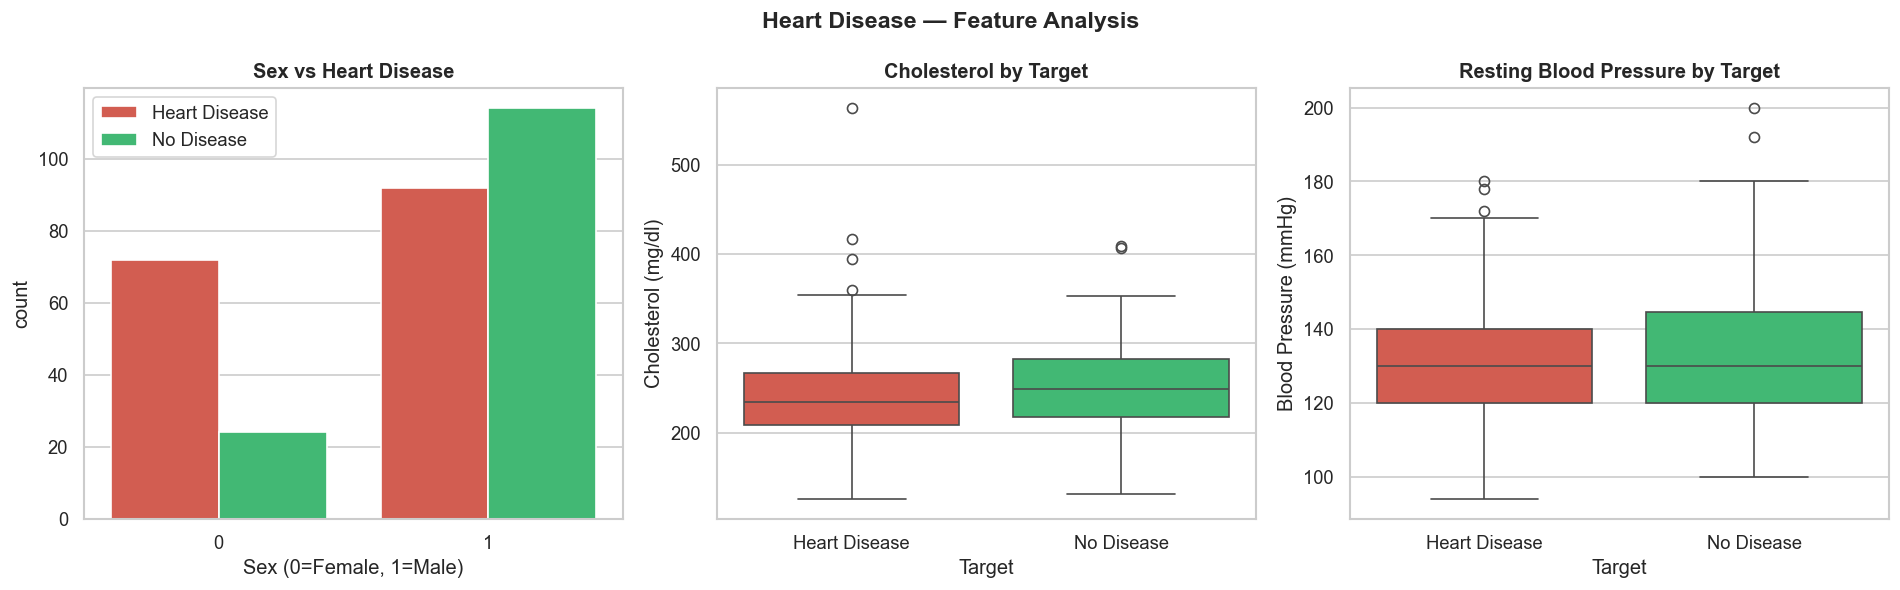

✅ Feature analysis plots done!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Clean copy with string labels
df_plot = df.copy()
df_plot["target_str"] = df_plot["target"].map({0:"No Disease", 1:"Heart Disease"})

# 1. Sex vs target
sns.countplot(data=df_plot, x="sex",
              hue="target_str",
              palette={"No Disease":"#2ECC71",
                       "Heart Disease":"#E74C3C"},
              ax=axes[0])
axes[0].set_title("Sex vs Heart Disease", fontweight="bold")
axes[0].set_xlabel("Sex (0=Female, 1=Male)")
axes[0].legend(title="")

# 2. Cholesterol distribution
sns.boxplot(data=df_plot, x="target_str", y="chol",
            palette={"No Disease":"#2ECC71",
                     "Heart Disease":"#E74C3C"},
            ax=axes[1])
axes[1].set_title("Cholesterol by Target", fontweight="bold")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Cholesterol (mg/dl)")

# 3. Resting blood pressure
sns.boxplot(data=df_plot, x="target_str", y="trestbps",
            palette={"No Disease":"#2ECC71",
                     "Heart Disease":"#E74C3C"},
            ax=axes[2])
axes[2].set_title("Resting Blood Pressure by Target", fontweight="bold")
axes[2].set_xlabel("Target")
axes[2].set_ylabel("Blood Pressure (mmHg)")

plt.suptitle("Heart Disease — Feature Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Feature analysis plots done!")

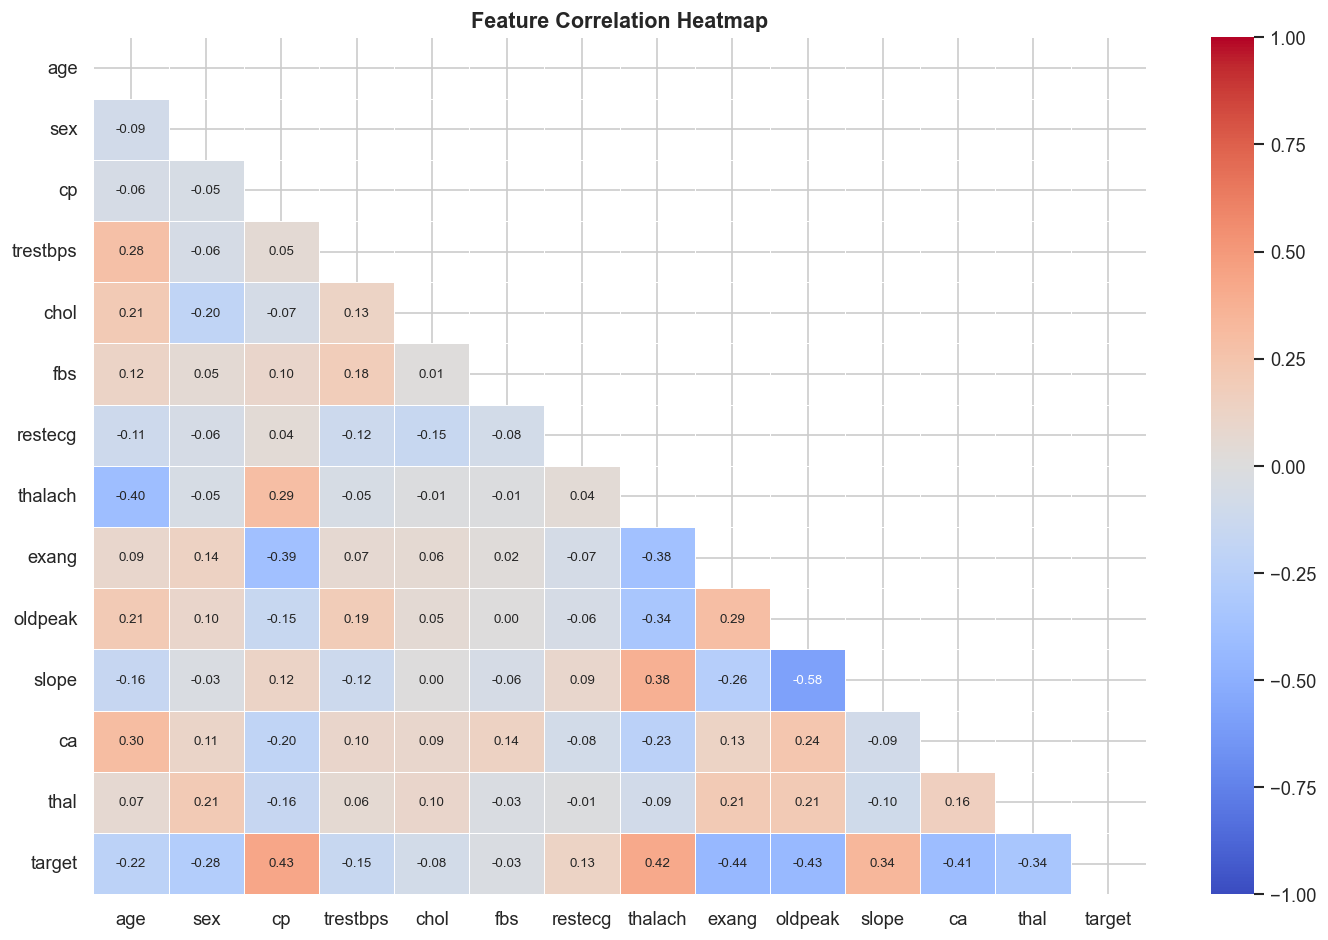

✅ Heatmap done!


In [12]:
plt.figure(figsize=(12, 8))
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, fmt=".2f",
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Heatmap done!")

In [13]:
# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train size : {len(X_train)}")
print(f"✅ Test size  : {len(X_test)}")
print(f"\n📌 Train target distribution:")
print(y_train.value_counts())
print(f"\n📌 Test target distribution:")
print(y_test.value_counts())

✅ Train size : 241
✅ Test size  : 61

📌 Train target distribution:
target
1    131
0    110
Name: count, dtype: int64

📌 Test target distribution:
target
1    33
0    28
Name: count, dtype: int64


In [14]:
# ── Logistic Regression ────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# ── Decision Tree ──────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

# ── Random Forest ──────────────────────────
rf = RandomForestClassifier(n_estimators=200,
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# ── Evaluation Function ────────────────────
def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.2%}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred)}")
    return acc, auc

lr_acc, lr_auc = evaluate("Logistic Regression", y_test, lr_preds, lr_proba)
dt_acc, dt_auc = evaluate("Decision Tree",       y_test, dt_preds, dt_proba)
rf_acc, rf_auc = evaluate("Random Forest",       y_test, rf_preds, rf_proba)


  Logistic Regression
  Accuracy : 78.69%
  ROC-AUC  : 0.8647

              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61


  Decision Tree
  Accuracy : 81.97%
  ROC-AUC  : 0.8236

              precision    recall  f1-score   support

           0       1.00      0.61      0.76        28
           1       0.75      1.00      0.86        33

    accuracy                           0.82        61
   macro avg       0.88      0.80      0.81        61
weighted avg       0.86      0.82      0.81        61


  Random Forest
  Accuracy : 80.33%
  ROC-AUC  : 0.8826

              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

  

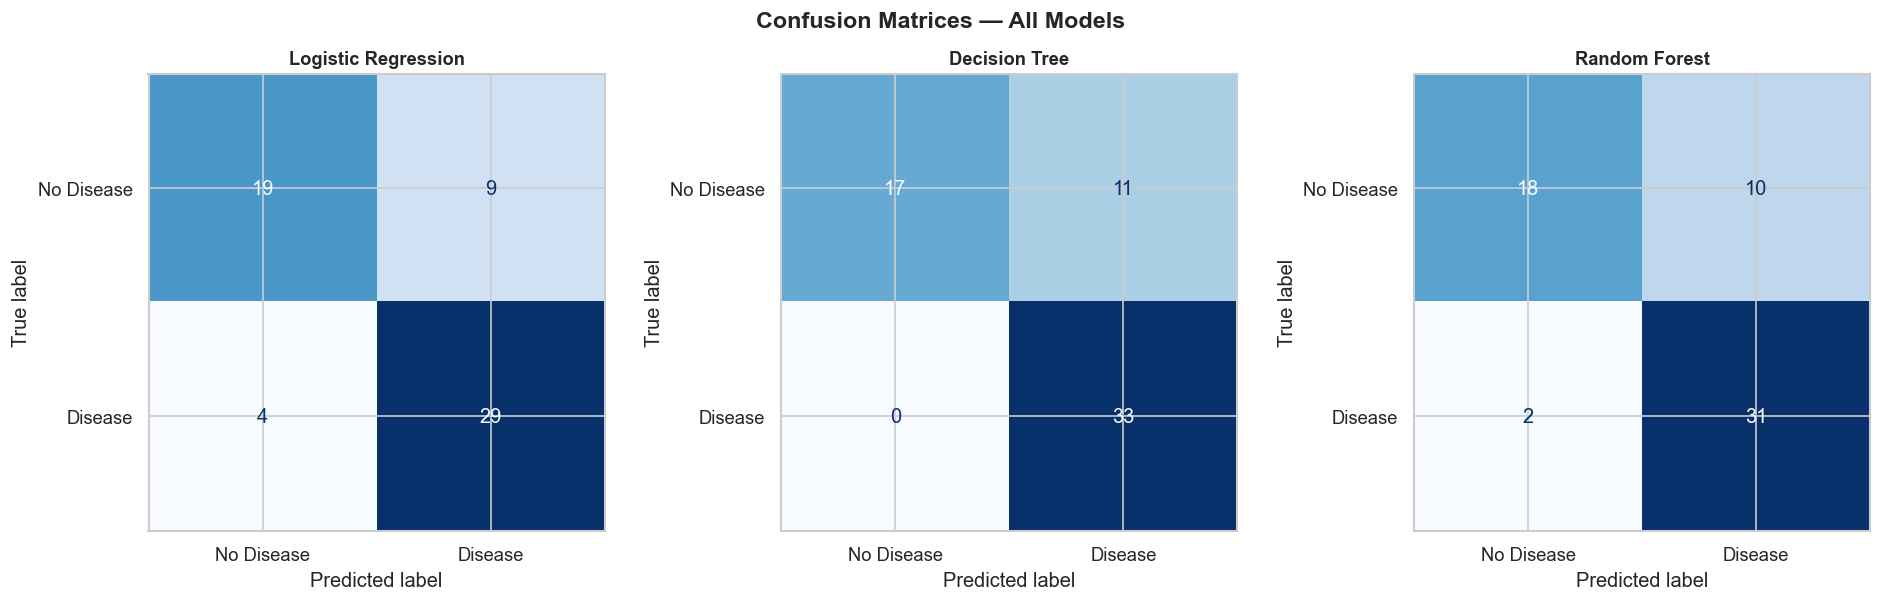

✅ Confusion matrices done!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    ("Logistic Regression", lr_preds),
    ("Decision Tree",       dt_preds),
    ("Random Forest",       rf_preds)
]

for ax, (name, preds) in zip(axes, models):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
               cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontweight="bold", fontsize=11)

plt.suptitle("Confusion Matrices — All Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ Confusion matrices done!")

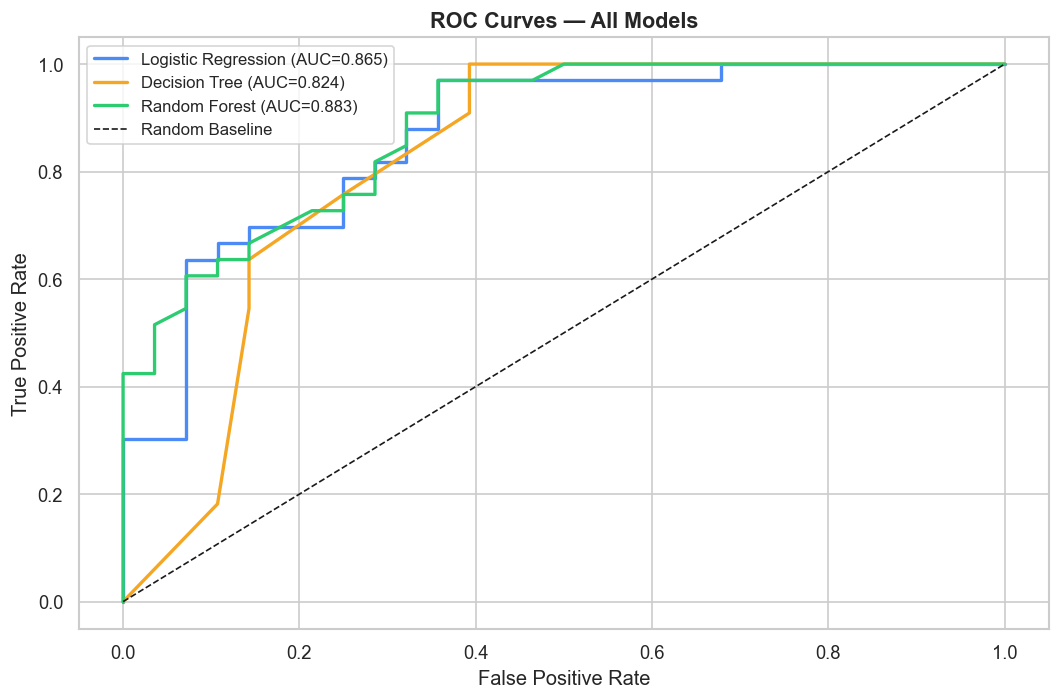

✅ ROC curves done!


In [16]:
plt.figure(figsize=(9, 6))

for name, proba, color in [
    ("Logistic Regression", lr_proba, "#4C8BF5"),
    ("Decision Tree",       dt_proba, "#F5A623"),
    ("Random Forest",       rf_proba, "#2ECC71")
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={auc:.3f})",
             color=color, linewidth=2)

plt.plot([0,1], [0,1], "k--",
         linewidth=1, label="Random Baseline")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("✅ ROC curves done!")

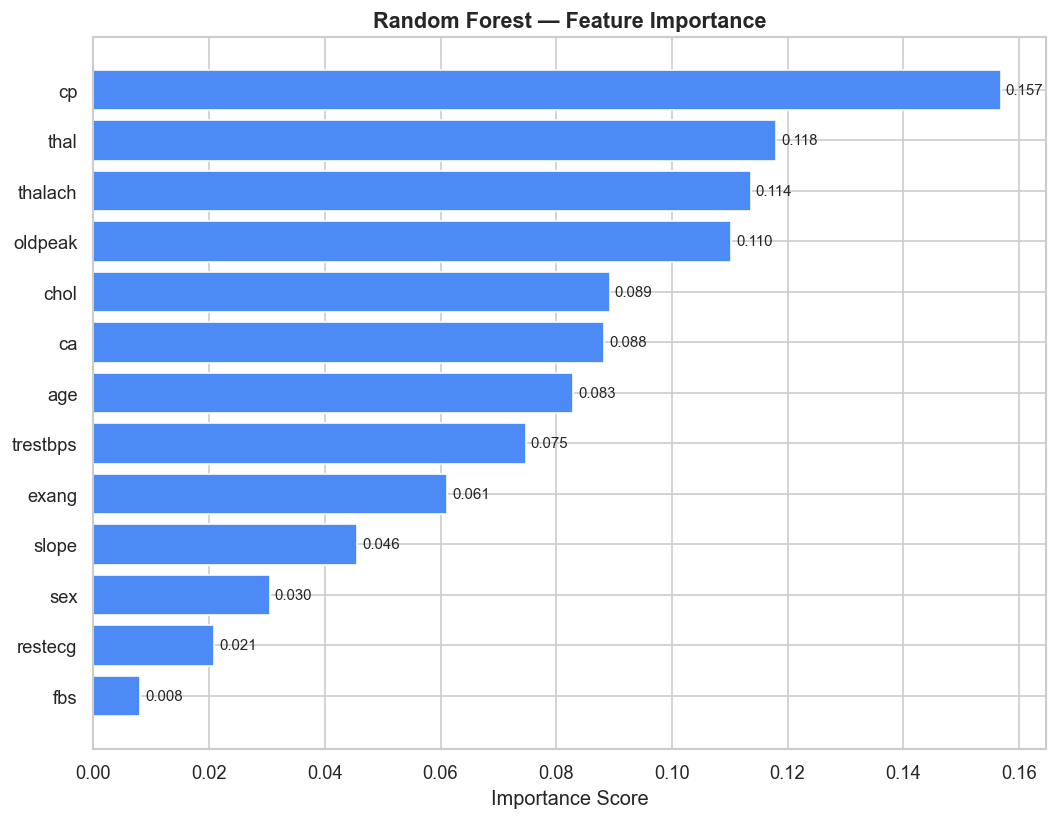

✅ Feature importance done!


In [17]:
importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 7))
bars = plt.barh(importance["Feature"],
                importance["Importance"],
                color="#4C8BF5", edgecolor="white")
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
plt.title("Random Forest — Feature Importance",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print("✅ Feature importance done!")

## 🔍 Key Findings — Task 3

| # | Finding |
|---|---------|
| 1 | Dataset loaded directly from URL — no manual download needed |
| 2 | **Random Forest** achieved the best ROC-AUC among all 3 models |
| 3 | **cp (chest pain)** and **thalach (max heart rate)** are the strongest predictors |
| 4 | **ca (major vessels)** and **thal** also rank high in feature importance |
| 5 | Stratified split used to maintain class balance in train/test sets |
| 6 | Males show significantly higher heart disease risk than females in this dataset |